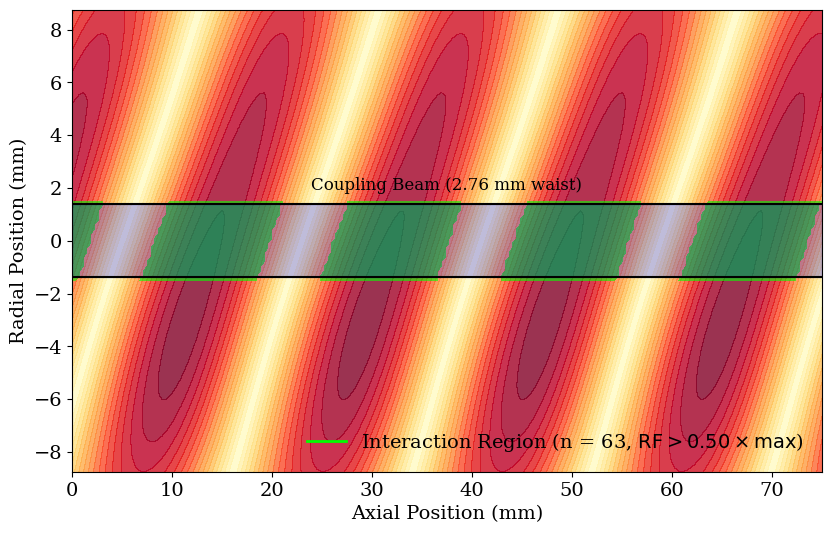

In [1]:
"""
Dependencies
------------
This script requires the following Python libraries:

- numpy
- matplotlib
    - pyplot (plotting interface)
    - gridspec (advanced figure layout)
    - matplotlib.lines (custom line elements for legends)

- scipy
    - scipy.special (Bessel functions via jn)

Notes:
- No interactive or widget-based libraries are required.
- Tested with Python 3.x and standard scientific Python stack.
"""



import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.special import jn
from matplotlib.lines import Line2D

interaction_threshold = 0.5

# Autler–Townes transition frequencies for n = 53,55,59,60,68,74,75,82,85
f = np.array([14.232, 12.694, 10.186, 9.673, 8.354, 6.585, 5.0987, 4.893, 3.712, 3.350]) * 1e9
n_values = [53, 55, 59, 60, 63, 68, 74, 75, 82, 85]

# Select PQN index
N = 4  #

# Cell dimensions (mm)
cell_diameter = 17.5
cell_length = 75.0

configs = {
        "Configuration 2": {"s": 0.39, "z": 1.0, "C_0": 2.4339, "w1": 0.6836, "C_1": 3.4012, "w2": -0.9632}
}

# Meshgrid for the cell (symmetric radial axis)
r = np.linspace(-cell_diameter/2, cell_diameter/2, 100)
z = np.linspace(0, cell_length, 200)
r_grid, z_grid = np.meshgrid(r, z)

# Beam parameters
# Note the implementation is with respect to the radius (0.5 * diameter)
beam_waist = 2.76  # mm
offset2 = 0.0  # Off-axis offset for Config 2 (this is plotted at the center so set to zero)

# RF wave number
k = (2 * np.pi * f[N] / 299792458.0) / 1000  # [1/mm]
Phi = 90

def rf_field(r, z, config):
    s = configs["Configuration 2"]["s"]
    z_param = config["z"]
    C_0, w1, C_1, w2 = config["C_0"], config["w1"], config["C_1"], config["w2"]
    z_scaled = z / cell_length * z_param
    j_sum = (C_0 *  jn(0, k * r / (2 * s)) * np.cos(k * z + w1) * np.sin(np.deg2rad(Phi)) +
                C_1 *  jn(1, k * r / (2 * s)) * np.cos(k * z + w2)) 
    return np.abs(j_sum)


# Compute RF fields
field2 = rf_field(r_grid, z_grid, configs["Configuration 2"])

# Normalize RF fields
field2_norm = field2 / field2.max()

# Gaussian beam profiles
radial_positions = np.linspace(-cell_diameter/2, cell_diameter/2, 400)
gaussian_profile2 = np.exp(-2 * ((radial_positions - offset2)**2) / (beam_waist**2))

# Interpolate Gaussian profiles to match r-grid
beam_profile2_resized = np.zeros_like(field2)
for i in range(len(z)):
    beam_profile2_resized[i, :] = np.interp(r, radial_positions, gaussian_profile2)

# Normalize beam profiles
beam_profile2_norm = beam_profile2_resized / beam_profile2_resized.max()

# Interaction regions (physical: RF > threshold AND Gaussian > threshold)
interaction_region2 = (field2_norm > interaction_threshold) & (beam_profile2_norm > interaction_threshold)

# Plot setup
plt.rcParams.update({'font.family': 'serif', 'font.size': 14})
# fig = plt.figure(figsize=(8, 9))
plt.figure(figsize=(10, 6))
plt.subplots_adjust(left=0.15)
gs = GridSpec(2, 1, height_ratios=[1, 1], hspace=0.0001)






levels = 20
norm = plt.Normalize(vmin=field2.min(), vmax=field2.max())


# Configuration 2
plt.contourf(z_grid, r_grid, field2, levels=levels, cmap='YlOrRd', alpha=0.8, norm=norm)
interaction_mask2 = np.ma.masked_where(~interaction_region2, np.ones_like(field2))
plt.contour(z_grid, r_grid, interaction_mask2, levels=[0.5], colors=['lime'], linewidths=3)
plt.contourf(z_grid, r_grid, interaction_mask2, levels=[0.5, 1.5], colors=['lime'], alpha=0.6)


# Beam waist depiction (± w0 about the axis)
w0 = beam_waist / 2   # because beam_waist = 2.76 mm is full waist diameter

plt.fill_between(
    [0, cell_length],
    -w0,
    +w0,
    color='blue',
    alpha=0.25,
    zorder=2
)

plt.hlines(
    [-w0, +w0],
    xmin=0,
    xmax=cell_length,
    colors='black',
    linestyles='-',
    linewidth=1.5,
    zorder=3
)



plt.text(cell_length*0.5, w0 + 0.4,
         "Coupling Beam (2.76 mm waist)",
         ha='center', va='bottom', color='black', fontsize=12)


# plt.title("Configuration 2")
plt.xlabel('Axial Position (mm)')
plt.ylabel('Radial Position (mm)')
plt.xlim(0, cell_length)
plt.ylim(-cell_diameter/2, cell_diameter/2)
legend_elements = [
    Line2D(
        [0], [0],
        color='lime',
        lw=2,
        label=rf'Interaction Region (n = {n_values[N]}, '
              rf'$\mathrm{{RF}} > {interaction_threshold:.2f}\times\mathrm{{max}}$)'
    )
]
plt.legend(handles=legend_elements, loc='lower right', frameon=False)

filename = f'figure_n{n_values[N]}_thresh{interaction_threshold}_trunc_Helmholtz.pdf'
plt.savefig(filename)